# 다항 회귀 : 2차함수 이상의 다항함수 

In [216]:
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. 데이터 불러오기
boston = load_boston()
df = pd.DataFrame(boston.data, columns=boston.feature_names)
df["medv"] = boston.target
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,medv
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


## 방법 1
- **예측 성능이 목적** → train/test 분할
- 결정계수, MSE 밖에 못구한다. 각 계수의 유의성 못봄. 

In [217]:
# 2. 독립변수와 종속변수 지정
X = df[["LSTAT"]]   # 하위계층 비율
y = df["medv"]

# 3. Train/Test 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# 4. 다항 특징 생성
# 모델2: 2차항
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_2 = poly2.fit_transform(X_train)
X_test_2 = poly2.transform(X_test)

model2 = LinearRegression().fit(X_train_2, y_train)


# 모델5: 5차항
poly5 = PolynomialFeatures(degree=5, include_bias=False)
X_train_5 = poly5.fit_transform(X_train)
X_test_5 = poly5.transform(X_test)

model5 = LinearRegression().fit(X_train_5, y_train)

In [218]:
# 5. 성능 비교
from sklearn.metrics import mean_squared_error, r2_score

pred2 = model2.predict(X_test_2)
pred5 = model5.predict(X_test_5)

print("Model2 - MSE:", mean_squared_error(y_test, pred2), "R²:", r2_score(y_test, pred2))
print("Model5 - MSE:", mean_squared_error(y_test, pred5), "R²:", r2_score(y_test, pred5))

Model2 - MSE: 33.71764821846763 R²: 0.5924658205706048
Model5 - MSE: 31.091860276763818 R²: 0.6242028600949615


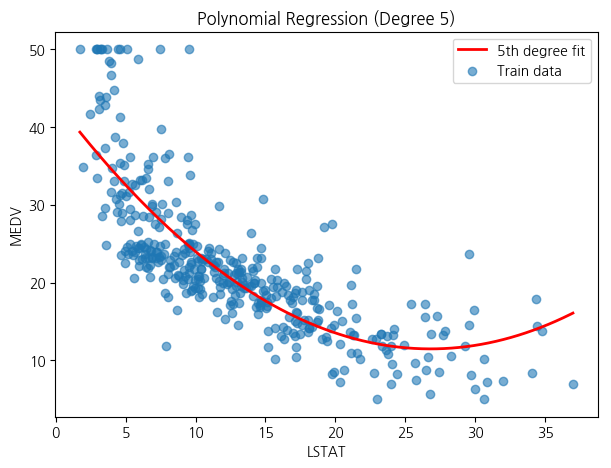

In [219]:
# 예측 곡선용 grid
x_grid = np.linspace(X_train.min(), X_train.max(), 200).reshape(-1, 1)
x_grid_poly2 = poly2.transform(x_grid)
y_pred_grid2 = model2.predict(x_grid_poly2)

# 시각화
plt.figure(figsize=(7,5))
plt.scatter(X_train, y_train, alpha=0.6, label="Train data")
plt.plot(x_grid, y_pred_grid2, color="red", linewidth=2, label="5th degree fit")
plt.xlabel("LSTAT")
plt.ylabel("MEDV")
plt.title("Polynomial Regression (Degree 5)")
plt.legend()
plt.show()

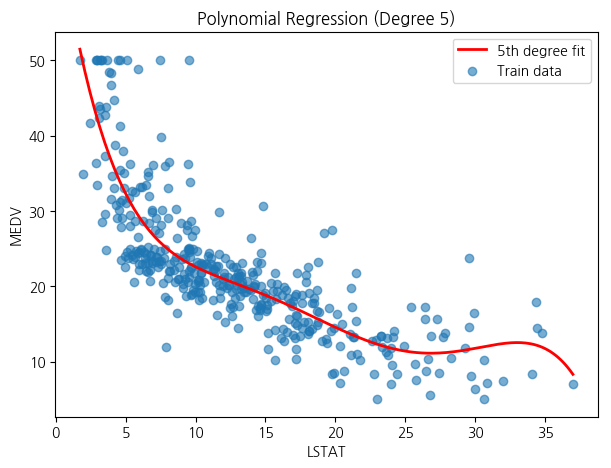

In [118]:
# 예측 곡선용 grid
x_grid = np.linspace(X_train.min(), X_train.max(), 200).reshape(-1, 1)
x_grid_poly5 = poly5.transform(x_grid)
y_pred_grid5 = model5.predict(x_grid_poly5)

# 시각화
plt.figure(figsize=(7,5))
plt.scatter(X_train, y_train, alpha=0.6, label="Train data")
plt.plot(x_grid, y_pred_grid5, color="red", linewidth=2, label="5th degree fit")
plt.xlabel("LSTAT")
plt.ylabel("MEDV")
plt.title("Polynomial Regression (Degree 5)")
plt.legend()
plt.show()

## 방법2  : Statsmodel 쓰는 방법 
- 수의 유의성, 표준오차, 가설검정, 잔차진단 등 **통계적 추론**이 중심 
- **전 표본을 써서** 정보(표본 크기)를 극대화해 더 작은 표준오차와 높은 검정력을 얻음 
- Residual Standard Error 알 수 있음. 

In [221]:
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures

# 2. 독립변수와 종속변수 지정
X = df[["LSTAT"]]   # 하위계층 비율
y = df["medv"]

# 다항 특징 생성 (degree=2)
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X2 = poly2.fit_transform(X)

# statsmodels는 수동으로 상수항 추가 필요
X2_const = sm.add_constant(X2)

# OLS 적합
model2_sm = sm.OLS(y, X2_const).fit()

# summary 출력
model2_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.641
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     448.5
Date:                Mon, 25 Aug 2025   Prob (F-statistic):          1.56e-112
Time:                        12:01:46   Log-Likelihood:                -1581.3
No. Observations:                 506   AIC:                             3169.
Df Residuals:                     503   BIC:                             3181.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         42.8620      0.872     49.149      0.000      41.149      44.575
x1            -2.3328      0.124    -18.843      0.000      -2.576      -2.090
x2             0.0435      0.004     11.628      0.000       0.036       0.051
==============================================================================
Omnibus:                      107.006   Durbin-Watson:                   0.921
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              228.388
Skew:                           1.128   Prob(JB):                     2.55e-50
Kurtosis:                       5.397   Cond. No.                     1.13e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.13e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [222]:
np.sqrt(model2_sm.mse_resid) # Residual Standard Error

5.523714131805206

In [223]:
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures

# 다항 특징 생성 (degree=2)
poly5 = PolynomialFeatures(degree=5, include_bias=False)
X5 = poly5.fit_transform(X)

# statsmodels는 수동으로 상수항 추가 필요
X5_const = sm.add_constant(X5)

# OLS 적합
model5_sm = sm.OLS(y, X5_const).fit()

# summary 출력
model5_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                     214.2
Date:                Mon, 25 Aug 2025   Prob (F-statistic):          8.73e-122
Time:                        12:01:53   Log-Likelihood:                -1550.6
No. Observations:                 506   AIC:                             3113.
Df Residuals:                     500   BIC:                             3139.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         67.6997      3.604     18.783      0.000      60.618      74.781
x1           -11.9911      1.526     -7.859      0.000     -14.989      -8.994
x2             1.2728      0.223      5.703      0.000       0.834       1.711
x3            -0.0683      0.014     -4.747      0.000      -0.097      -0.040
x4             0.0017      0.000      4.143      0.000       0.001       0.003
x5         -1.632e-05   4.42e-06     -3.692      0.000    -2.5e-05   -7.63e-06
==============================================================================
Omnibus:                      144.085   Durbin-Watson:                   0.987
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              494.545
Skew:                           1.292   Prob(JB):                    4.08e-108
Kurtosis:                       7.096   Cond. No.                     1.37e+08
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.37e+08. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [224]:
np.sqrt(model5_sm.mse_resid)

5.214793385641508

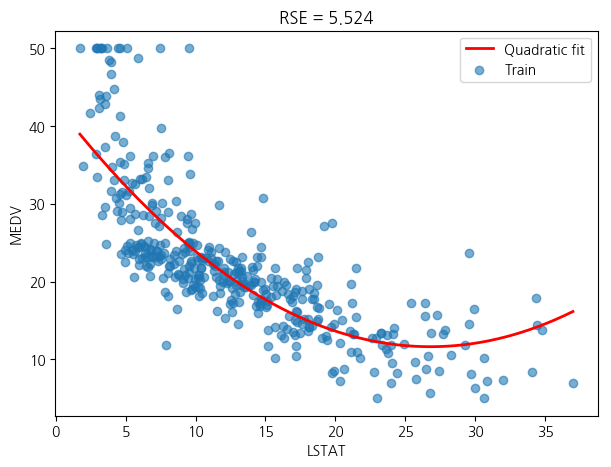

In [226]:
x_grid = np.linspace(X_train["LSTAT"].min(), X_train["LSTAT"].max(), 300).reshape(-1, 1)
Xg_poly = poly2.transform(x_grid)
Xg_const = sm.add_constant(Xg_poly)
y_grid_pred = model2_sm.predict(Xg_const)

plt.figure(figsize=(7,5))
plt.scatter(X_train["LSTAT"].values, y_train.values, alpha=0.6, label="Train")
plt.plot(x_grid, y_grid_pred, color="red",linewidth=2, label="Quadratic fit")
plt.title(f"RSE = {np.sqrt(model2_sm.mse_resid):.3f}")
plt.xlabel("LSTAT")
plt.ylabel("MEDV")
plt.legend()
plt.show()

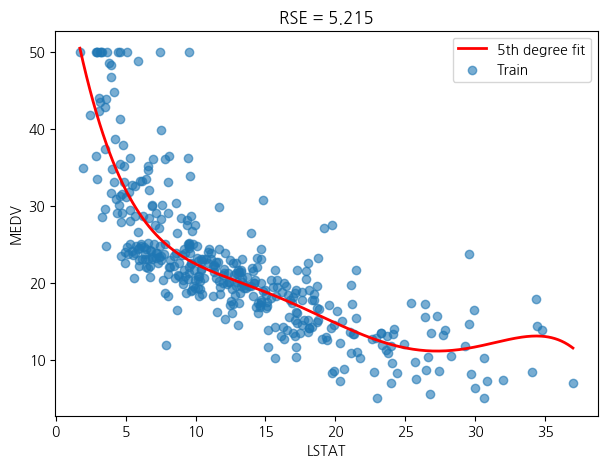

In [192]:
x_grid = np.linspace(X_train["LSTAT"].min(), X_train["LSTAT"].max(), 300).reshape(-1, 1)
Xg_poly = poly5.transform(x_grid)
Xg_const = sm.add_constant(Xg_poly)
y_grid_pred = model5_sm.predict(Xg_const)

plt.figure(figsize=(7,5))
plt.scatter(X_train["LSTAT"].values, y_train.values, alpha=0.6, label="Train")
plt.plot(x_grid, y_grid_pred, color="red",linewidth=2, label="5th degree fit")
plt.title(f"RSE = {np.sqrt(model5_sm.mse_resid):.3f}")
plt.xlabel("LSTAT")
plt.ylabel("MEDV")
plt.legend()
plt.show()

# 데이터 만든 것으로 다항회귀

In [205]:
import koreanize_matplotlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# 1. 데이터 생성
np.random.seed(0)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 2*X.squeeze()**3 - 3*X.squeeze()**2 + X.squeeze() + np.random.normal(0, 7, size=100)


# 2. 이상치 추가
y_outlier = y.copy()
outlier_idx = np.random.choice(len(y), size=5, replace=False)  # 5개 점 무작위 선택
y_outlier[outlier_idx] += np.random.normal(30, 5, size=5)      # 큰 양수 편차 추가
y_outlier[outlier_idx[:2]] -= np.random.normal(30, 5, size=2)  # 일부는 큰 음수 편차


# 2. 다항 특성 생성 (차수 d 선택)
poly = PolynomialFeatures(degree=3, include_bias=False) # 차수 3차 
X_poly = poly.fit_transform(X)

model_poly = LinearRegression()
model_poly.fit(X_poly, y_outlier)
y_pred_poly = model_poly.predict(X_poly)

# 3. 선형 회귀 모델 학습
model_linear = LinearRegression()
model_linear.fit(X, y_outlier)
y_pred_linear = model_linear.predict(X)

# 4. 성능 비교
print("선형 회귀 성능:")
print(f" - MSE : {mean_squared_error(y_outlier, y_pred_linear):.4f}")
print(f" - R²  : {r2_score(y_outlier, y_pred_linear):.4f}")

print("\n다항 회귀 성능:")
print(f" - MSE : {mean_squared_error(y_outlier, y_pred_poly):.4f}")
print(f" - R²  : {r2_score(y_outlier, y_pred_poly):.4f}")

선형 회귀 성능:
 - MSE : 178.3035
 - R²  : 0.6999

다항 회귀 성능:
 - MSE : 68.7217
 - R²  : 0.8843


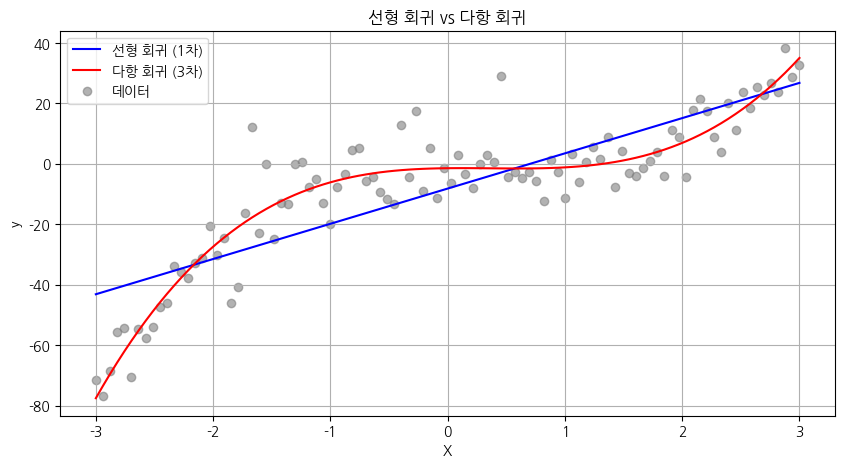

In [206]:
# 5. 시각화
plt.figure(figsize=(10, 5))
plt.scatter(X, y_outlier, color='gray', alpha=0.6, label='데이터')
plt.plot(X, y_pred_linear, color='blue', label='선형 회귀 (1차)')
plt.plot(X, y_pred_poly, color='red', label='다항 회귀 (3차)')
plt.title('선형 회귀 vs 다항 회귀')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# 최소자승법으로 다항회귀

In [212]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# 1. 데이터 생성
np.random.seed(0)
X = np.linspace(-3, 3, 100).reshape(-1, 1)
y = 2*X.squeeze()**3 - 3*X.squeeze()**2 + X.squeeze() + np.random.normal(0, 7, size=100)


# 2. 이상치 추가
y_outlier = y.copy()
outlier_idx = np.random.choice(len(y), size=5, replace=False)  # 5개 점 무작위 선택
y_outlier[outlier_idx] += np.random.normal(30, 5, size=5)      # 큰 양수 편차 추가
y_outlier[outlier_idx[:2]] -= np.random.normal(30, 5, size=2)  # 일부는 큰 음수 편차


# 다항 특징 생성 (degree=2)
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X2 = poly2.fit_transform(X)

# statsmodels는 수동으로 상수항 추가 필요
X2_const = sm.add_constant(X2)

# OLS 적합
model2_sm = sm.OLS(y_outlier, X2_const).fit()

y_pred2 = model2_sm.predict(X2_const)

# summary 출력
print(model2_sm.summary())


# 다항 특성 생성 (예: 3차)
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X3 = poly3.fit_transform(X)

# 3. statsmodels의 OLS 모델에 맞게 상수항 추가
X3_const = sm.add_constant(X3)

# 4. OLS 적합
model3_sm = sm.OLS(y_outlier, X3_const).fit()

# 5. 예측
y_pred3 = model3_sm.predict(X3_const)

# 6. 결과 출력
print(model3_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     154.4
Date:                Mon, 25 Aug 2025   Prob (F-statistic):           7.10e-31
Time:                        11:59:10   Log-Likelihood:                -389.68
No. Observations:                 100   AIC:                             785.4
Df Residuals:                      97   BIC:                             793.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4576      1.815     -0.803      0.4

In [210]:
np.sqrt(model2_sm.mse_resid) # Residual Standard Error degree : 2

12.098551098176204

In [211]:
np.sqrt(model3_sm.mse_resid) # Residual Standard Error degree : 3

8.46080064914279

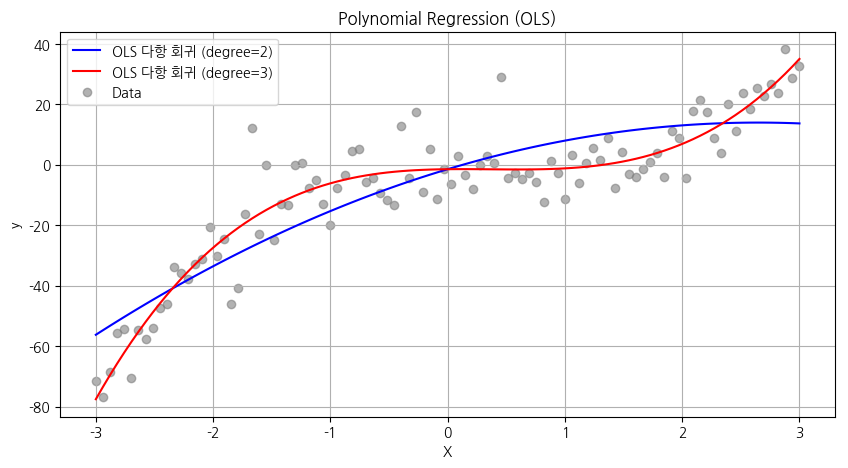

In [214]:
# 7. 시각화
plt.figure(figsize=(10, 5))
plt.scatter(X, y_outlier, color='gray', alpha=0.6, label='Data')
plt.plot(X, y_pred2, color='blue', label='OLS 다항 회귀 (degree=2)')
plt.plot(X, y_pred3, color='red', label='OLS 다항 회귀 (degree=3)')
plt.title('Polynomial Regression (OLS)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# 스플라인 회귀
- 다항 구간들을 부드러운 곡선 형태로 적합 
- 매듭의 개수와 차수를 지정함 

In [227]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from patsy import dmatrix

# 1. 데이터 생성
np.random.seed(42)
X = np.linspace(0, 10, 100)
y = np.piecewise(X, [X < 3, (X >= 3) & (X < 7), X >= 7],
                 [lambda x: 2*x + 1,
                  lambda x: -x + 10,
                  lambda x: 0.5*x + 1.5]) + np.random.normal(0, 1, 100)

# 2. B-spline 특성 생성
X_spline = dmatrix("bs(x, knots=(3, 7), degree=3, include_intercept=False)", {"x": X}, return_type='dataframe')

# 3. OLS 적합
model = sm.OLS(y, X_spline).fit()
y_pred = model.predict(X_spline)

/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1377: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/Users/sin-yuwon/test/.venv/lib/python3.7/site-packages/matplotlib/axes/_base.py:239: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


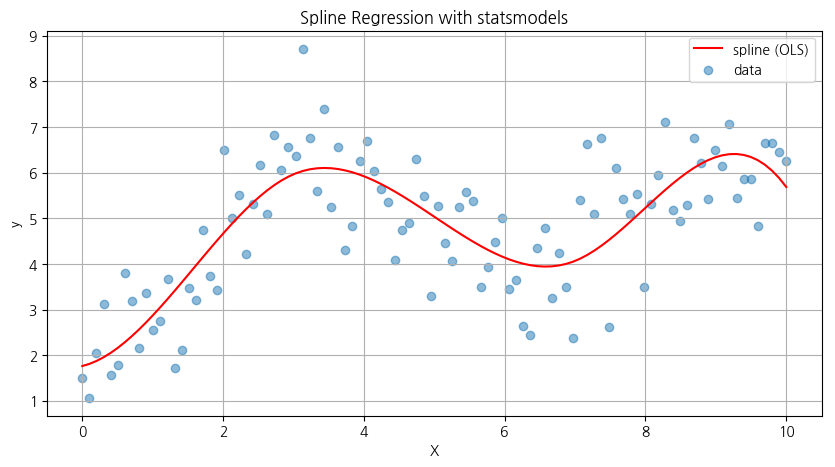

In [228]:
# 4. 시각화
plt.figure(figsize=(10, 5))
plt.scatter(X, y, label='data', alpha=0.5)
plt.plot(X, y_pred, color='red', label='spline (OLS)')
plt.title("Spline Regression with statsmodels")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

In [229]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.608
Method:                 Least Squares   F-statistic:                     31.66
Date:                Mon, 25 Aug 2025   Prob (F-statistic):           8.95e-19
Time:                        12:05:42   Log-Likelihood:                -137.62
No. Observations:                 100   AIC:                             287.2
Df Residuals:                      94   BIC:                             302.9
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=============================================================================================================================
                                                                coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------
Intercept                                                     1.7618      0.534      3.302      0.001       0.702       2.821
bs(x, knots=(3, 7), degree=3, include_intercept=False)[0]     0.3680      0.973      0.378      0.706      -1.563       2.299
bs(x, knots=(3, 7), degree=3, include_intercept=False)[1]     7.7822      0.704     11.051      0.000       6.384       9.180
bs(x, knots=(3, 7), degree=3, include_intercept=False)[2]    -1.2235      0.940     -1.301      0.196      -3.090       0.643
bs(x, knots=(3, 7), degree=3, include_intercept=False)[3]     6.0354      0.737      8.194      0.000       4.573       7.498
bs(x, knots=(3, 7), degree=3, include_intercept=False)[4]     3.9245      0.774      5.068      0.000       2.387       5.462
==============================================================================
Omnibus:                        0.900   Durbin-Watson:                   1.904
Prob(Omnibus):                  0.638   Jarque-Bera (JB):                0.765
Skew:                           0.213   Prob(JB):                        0.682
Kurtosis:                       2.962   Cond. No.                         16.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# 로그 변환으로 선형성 만족하도록 

In [134]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import skew, boxcox
from statsmodels.stats.diagnostic import het_breuschpagan

# 1) 데이터 로드 & 전처리
df = sns.load_dataset("planets").dropna()

In [135]:
df.head()
# planet data
# orbital_period : 공전주기 
# mass : 질량 
# distance : 거리

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [149]:
df = df[df['method']=='Radial Velocity']

In [150]:
# 2) 분포/스큐 확인
df.describe() # 모두 0보다 큰 양의 숫자 (로그 변환 고려 사항)

,number,orbital_period,mass,distance,year
count,497.000000,497.000000,497.000000,497.000000,497.000000
mean,1.736419,837.454878,2.511411,51.814829,2007.366197
std,1.176441,1470.131725,3.639638,46.298280,4.163821
min,1.000000,1.328300,0.003600,1.350000,1989.000000
25%,1.000000,39.026000,0.210000,24.150000,2005.000000
50%,1.000000,358.000000,1.240000,39.560000,2009.000000
75%,2.000000,1001.700000,2.880000,59.280000,2011.000000
max,6.000000,17337.500000,25.000000,354.000000,2014.000000


In [156]:
print("period: ",df['orbital_period'].skew(), "mass:", df['mass'].skew(), "distance:",df['distance'].skew())

period:  5.289564762820483 mass: 2.5864550566135263 distance: 2.8315251226385385


In [ ]:
# 세 변수 모두 오른쪽으로 긴 꼬리가 있는 심한 양의 왜도(heavy right skew) 를 보인다.
# → 로그변환이 분포를 안정화하고(정규성에 근접), 분산 불균등(heteroscedasticity)을 완화시킨다.

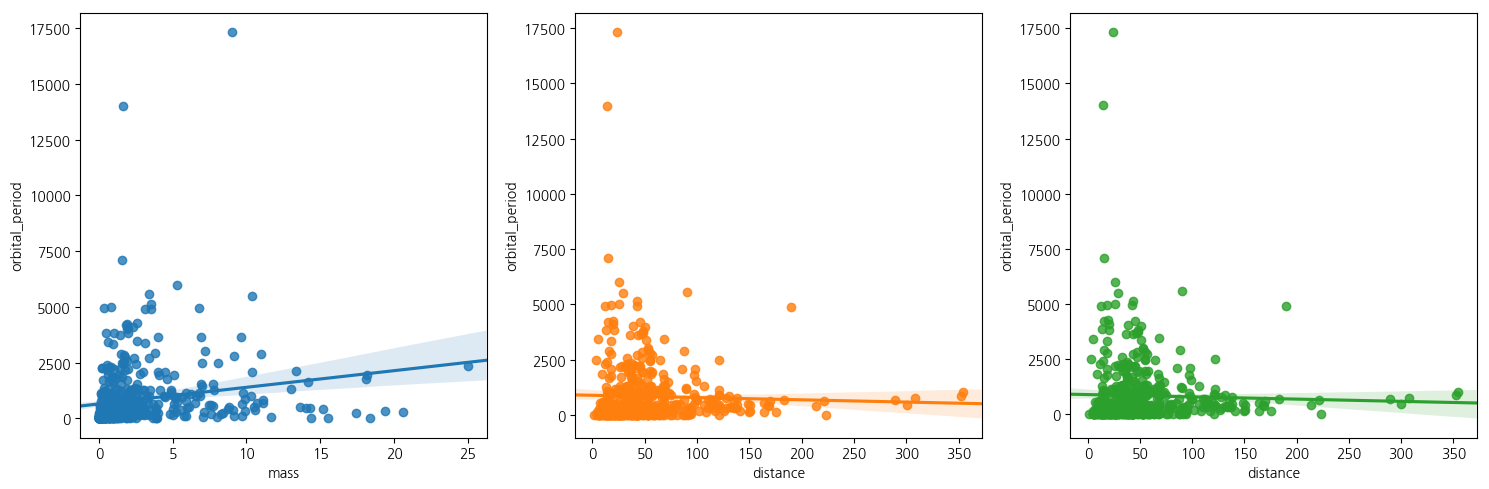

In [157]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

sns.regplot(x="mass", y="orbital_period", data=df, ax=axes[0])
sns.regplot(x="distance", y="orbital_period", data=df, ax=axes[1])
sns.regplot(x="distance", y="orbital_period", data=df, ax=axes[2])
plt.tight_layout()
plt.show()

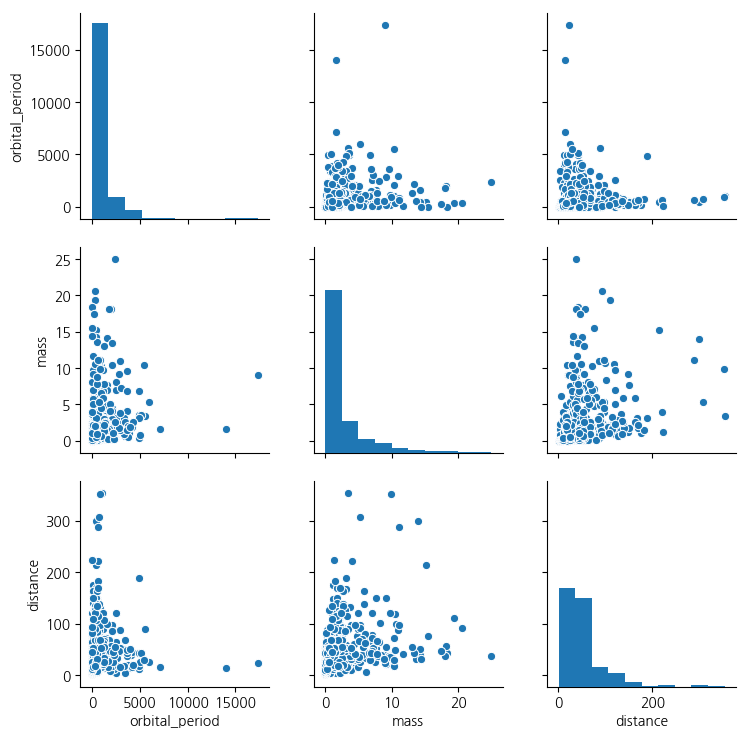

In [158]:
# 3) 산점도(원스케일)
sns.pairplot(df, vars=['orbital_period','mass','distance'], kind='scatter', diag_kind='hist')
plt.show()

In [173]:
# 기준 모형 : m0
m0 = smf.ols("orbital_period ~ mass + distance", data=df).fit()
m0.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         orbital_period   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     10.74
Date:                Mon, 25 Aug 2025   Prob (F-statistic):           2.73e-05
Time:                        11:26:20   Log-Likelihood:                -4318.8
No. Observations:                 497   AIC:                             8644.
Df Residuals:                     494   BIC:                             8656.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    773.5261    100.445      7.701      0.000     576.173     970.879
mass          84.7366     18.519      4.576      0.000      48.350     121.123
distance      -2.8733      1.456     -1.974      0.049      -5.734      -0.013
==============================================================================
Omnibus:                      561.092   Durbin-Watson:                   2.015
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            41987.774
Skew:                           5.174   Prob(JB):                         0.00
Kurtosis:                      46.823   Cond. No.                         108.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [174]:
m0.mse_resid      # 평균제곱오차 (RSS / df_resid)
np.sqrt(m0.mse_resid)   # Residual standard error

1442.0981631364941

In [160]:
# 잔차 진단: 등분산성(Breusch-Pagan)
bp_stat, bp_p, _, _ = het_breuschpagan(m0.resid, m0.model.exog)
print(f"BP test p-value (M0): {bp_p:.4g}")

# BP 검정의 p-value가 0.05보다 작으므로 귀무가설을 기각하여 등분산성 가정을 위배한다.

BP test p-value (M0): 0.03428


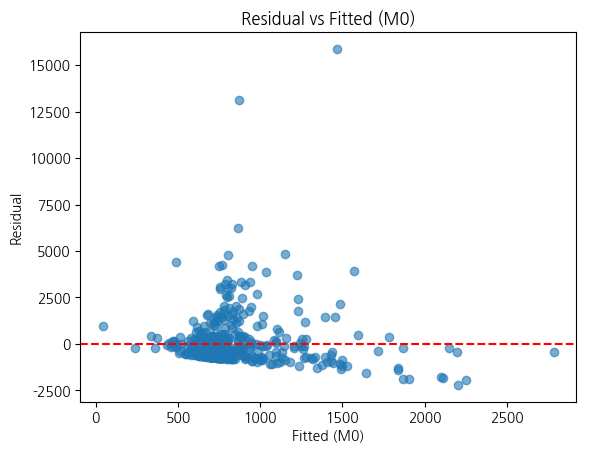

In [161]:
# 잔차 플롯 : 선형성 확인
fig, ax = plt.subplots()
ax.scatter(m0.fittedvalues, m0.resid, alpha=.6)
ax.axhline(0, ls='--', c='r')
ax.set(xlabel='Fitted (M0)', ylabel='Residual', title='Residual vs Fitted (M0)')
plt.show()
# 이상치가 존재함을 알 수 있다.

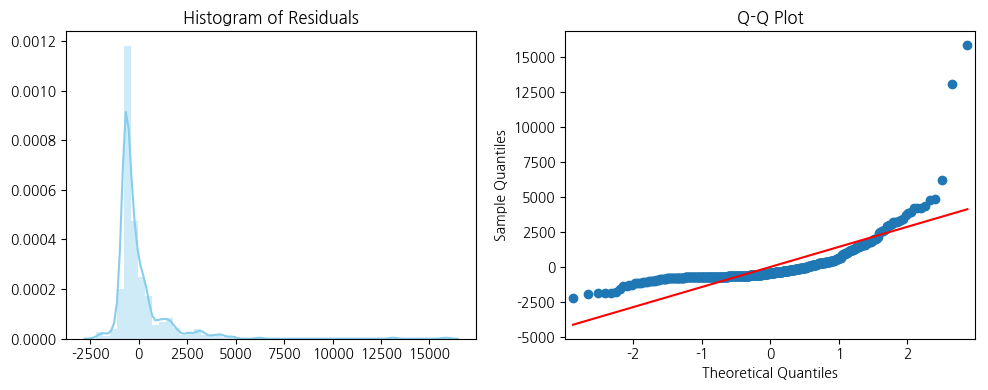

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1,2, figsize = (10,4))

# 히스토그램 + KDE
sns.distplot(m0.resid, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title("Histogram of Residuals")

# Q-Q plot (정규성 확인)
sm.qqplot(m0.resid, line='s', ax=ax[1])
ax[1].set_title("Q-Q Plot")
plt.tight_layout()
plt.show()

In [163]:
from scipy.stats import shapiro
stat, p = shapiro(m0.resid)
print(f"p-value가 {p:.3} 으로 유의수준 0.05 보다 작으므로 귀무가설을 기각하여 잔차의 정규성을 만족하지 못한다.'")

p-value가 1.1e-32 으로 유의수준 0.05 보다 작으므로 귀무가설을 기각하여 잔차의 정규성을 만족하지 못한다.'


In [164]:
from statsmodels.stats.stattools import jarque_bera 
stats, p, skew, kurt = jarque_bera(m0.resid)
print(f"jarque-bera test : stats {stats:.3f}, p-value {p:.3f}, 왜도 {skew:.3f}, 첨도{kurt:.3f}")
print("정규분포의 왜도는 0, 첨도는 3인 해당 기준으로는 다소 차이가 있다.")

jarque-bera test : stats 41987.774, p-value 0.000, 왜도 5.174, 첨도46.823
정규분포의 왜도는 0, 첨도는 3인 해당 기준으로는 다소 차이가 있다.


# 로그–로그 모형 M1

In [171]:
df1 = df.assign(
    log_period = np.log(df['orbital_period']),
    log_mass   = np.log(df['mass']),
    log_dist   = np.log(df['distance'])
)

m1 = smf.ols("log_period ~ log_mass + log_dist", data=df1).fit()
m1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             log_period   R-squared:                       0.355
Model:                            OLS   Adj. R-squared:                  0.353
Method:                 Least Squares   F-statistic:                     136.1
Date:                Mon, 25 Aug 2025   Prob (F-statistic):           8.54e-48
Time:                        11:25:27   Log-Likelihood:                -969.11
No. Observations:                 497   AIC:                             1944.
Df Residuals:                     494   BIC:                             1957.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.4533      0.412     15.659      0.000       5.644       7.263
log_mass       0.6893      0.045     15.199      0.000       0.600       0.778
log_dist      -0.2586      0.109     -2.365      0.018      -0.473      -0.044
==============================================================================
Omnibus:                       57.378   Durbin-Watson:                   1.971
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               78.066
Skew:                          -0.836   Prob(JB):                     1.12e-17
Kurtosis:                       3.987   Cond. No.                         21.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [172]:
m1.mse_resid      # 평균제곱오차 (RSS / df_resid)
np.sqrt(m1.mse_resid)   # Residual standard error

1.7057705998533252

BP test p-value (M1): 0.01086


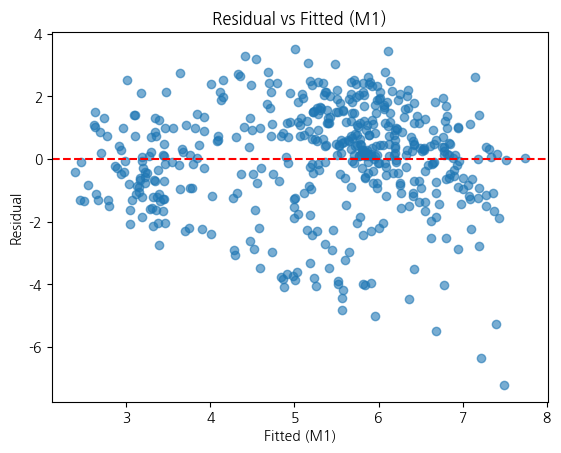

In [166]:
# 진단
bp_stat, bp_p, _, _ = het_breuschpagan(m1.resid, m1.model.exog)
print(f"BP test p-value (M1): {bp_p:.4g}")

fig, ax = plt.subplots()
ax.scatter(m1.fittedvalues, m1.resid, alpha=.6)
ax.axhline(0, ls='--', c='r')
ax.set(xlabel='Fitted (M1)', ylabel='Residual', title='Residual vs Fitted (M1)')
plt.show()

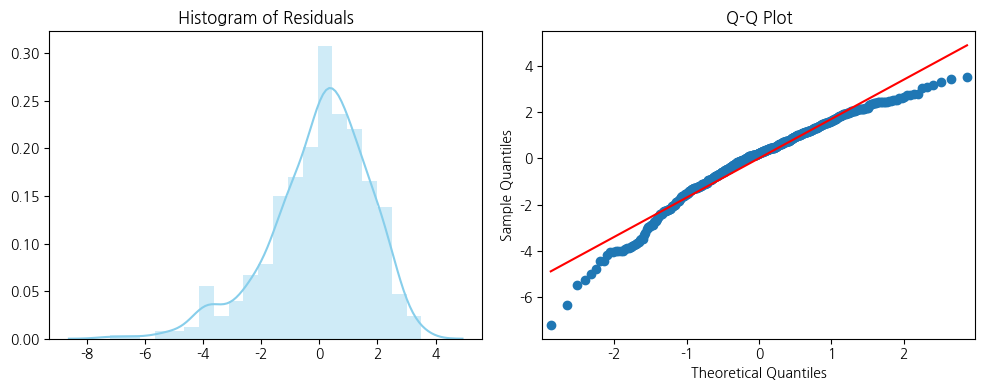

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1,2, figsize = (10,4))

# 히스토그램 + KDE
sns.distplot(m1.resid, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title("Histogram of Residuals")

# Q-Q plot (정규성 확인)
sm.qqplot(m1.resid, line='s', ax=ax[1])
ax[1].set_title("Q-Q Plot")
plt.tight_layout()
plt.show()

In [168]:
from scipy.stats import shapiro
stat, p = shapiro(m1.resid)
print(f"p-value가 {p:.3} 으로 유의수준 0.05 보다 작으므로 귀무가설을 기각하여 잔차의 정규성을 만족하지 못하지만 정규성 위배가 완화되었다.'")

p-value가 3.02e-10 으로 유의수준 0.05 보다 작으므로 귀무가설을 기각하여 잔차의 정규성을 만족하지 못하지만 정규성 위배가 완화되었다.'


In [170]:
from statsmodels.stats.stattools import jarque_bera 
stats, p, skew, kurt = jarque_bera(m1.resid)
print(f"jarque-bera test : stats {stats:.3f}, p-value {p:.3f}, 왜도 {skew:.3f}, 첨도{kurt:.3f}")
# 왜도와 첨도가 많이 낮아짐을 볼 수 있다.

jarque-bera test : stats 78.066, p-value 0.000, 왜도 -0.836, 첨도3.987
